In [1]:
import sys

import polars as pl
import torch

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfig
from modeling_module.models.PatchTST.common.configs import PatchTSTConfig, PatchTSTConfigWeekly
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

save_dir = DIR + 'fit/20251106_running'


True
1
12.8
2.9.0.dev20250716+cu128
NVIDIA GeForce RTX 5080
2.9.0.dev20250716+cu128


In [2]:
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet').sort(['oper_part_no', 'demand_dt'])
target_dyn_demand_weekly = (target_dyn_demand_weekly.group_by('oper_part_no', maintain_order = True).map_groups(lambda g: g.with_columns(pl.arange(1, len(g) + 1).alias('seq'))))

filtered_target = target_dyn_demand_weekly.group_by('oper_part_no').agg(pl.col('seq').max().alias('seq_max')).filter(pl.col('seq_max') > 260).select('oper_part_no')

target_dyn_demand_weekly = target_dyn_demand_weekly.join(filtered_target, on = 'oper_part_no', how = 'right').select(['oper_part_no', 'demand_dt', 'demand_qty'])
target_dyn_demand_weekly

oper_part_no,demand_dt,demand_qty
str,i64,f64
"""U3215-19062""",201802,5.0
"""U3215-19062""",201803,4.0
"""U3215-19062""",201804,7.0
"""U3215-19062""",201805,1.0
"""U3215-19062""",201806,7.0
…,…,…
"""82KP-3421""",202650,2.0
"""82KP-3421""",202652,268.0
"""82KP-3421""",202653,22.0


In [3]:
plan_yyyymm = 201811
lookback = 52
horizon = 27
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

data_module = MultiPartDataModule(
    target_dyn_demand_weekly.sort(['oper_part_no', 'demand_dt']),
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [4]:
from modeling_module.training.model_trainers.total_train import run_total_train_weekly

mode_dict = run_total_train_weekly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
)

PatchTST Base
PatchTST Base (Weekly)
[train_patchtst] ===== Stage 1/2 ===== - spike: OFF - epochs: 10 | lr=0.0003 | horizon_decay=False
[train_patchtst] Effective TrainingConfig:
{
  "device": "cuda",
  "lookback": 52,
  "horizon": 27,
  "epochs": 10,
  "lr": 0.0003,
  "weight_decay": 0.001,
  "t_max": 40,
  "patience": 100,
  "max_grad_norm": 30.0,
  "amp_device": "cuda",
  "loss_mode": "point",
  "point_loss": "huber",
  "huber_delta": 0.8,
  "q_star": 0.5,
  "use_cost_q_star": false,
  "Cu": 1.0,
  "Co": 1.0,
  "quantiles": [
    0.1,
    0.5,
    0.9
  ],
  "use_intermittent": true,
  "alpha_zero": 3.0,
  "alpha_pos": 1.0,
  "gamma_run": 0.3,
  "cap": null,
  "use_horizon_decay": false,
  "tau_h": 0.85,
  "val_use_weights": false,
  "spike_loss": {
    "enabled": false,
    "strategy": "mix",
    "huber_delta": 0.6,
    "asym_up_weight": 1.0,
    "asym_down_weight": 8.0,
    "mad_k": 1.5,
    "w_spike": 32.0,
    "w_norm": 1.0,
    "alpha_huber": 0.6,
    "beta_asym": 0.4,
    "mix

In [5]:
from modeling_module.models.Titan.common.configs import TitanConfig

pm_base_config = PatchMixerConfig(
        lookback = lookback,
        horizon = horizon,
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfig(
    lookback = lookback,
        horizon = horizon,
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)

ti_config = TitanConfig(
            lookback=lookback,
            horizon=horizon,
            # 아래는 Titans.py에서 사용하는 공통 옵션들(필요 시 설정)
            input_dim=1,  # 데이터로더 입력 채널 수에 맞춰 조정
            d_model=256,
            n_layers=3,
            n_heads=4,
            d_ff=512,
            dropout=0.1,
            contextual_mem_size=256, persistent_mem_size=64,
            use_exogenous=True, exo_dim=2,  # 캘린더 sin/cos 자동 주입 조건
            final_clamp_nonneg=False,
        )
#
pt_config = PatchTSTConfig(
        device = device,
        loss_mode = 'auto',
        quantiles = (0.1, 0.5, 0.9)
    )

cfg_map = {
    # "PatchMixer Base": pm_base_config,
    # "PatchMixer Quantile": pm_quantile_config,
    # "Titan Base": ti_config,
    # "Titan LMM": ti_config,
    # "Titan Seq2Seq": ti_config,
    "PatchTST Base": pt_config,
    "PatchTST Quantile": pt_config
}

In [6]:

models_only = {
    name: (pack["model"] if isinstance(pack, dict) and "model" in pack else pack)
    for name, pack in mode_dict.items()
}

# cfg_by_name도 맞춰서 준비(필요하면)
cfg_by_name = {
    name: (pack.get("cfg") if isinstance(pack, dict) else None)
    for name, pack in mode_dict.items()
}

builder_key_by_name = {
  # "PatchMixer Base": "patchmixer_base",
  # "PatchMixer Quantile": "patchmixer_quantile",
  # "Titan Base": "titan_base",
  # "Titan LMM": "titan_lmm",
  # "Titan Seq2Seq": "titan_seq2seq",
  "PatchTST Base": "patchtst_base",
  "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(
    models_only,
    save_dir,
    cfg_by_name=cfg_by_name,                 # None 가능
    builder_key_by_name=builder_key_by_name  # 기존 그대로
)

In [7]:

# Load
from modeling_module.models.model_builder import (
    build_titan_base, build_titan_lmm, build_titan_seq2seq, build_patch_mixer_base, build_patch_mixer_quantile,
    build_patchTST_base, build_patchTST_quantile,
)

builders = {
    # "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfig()),
    # "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfig()),
    # "titan_base": lambda cfg: build_titan_base(ti_config or TitanConfig()),
    # "titan_lmm": lambda cfg: build_titan_lmm(ti_config or TitanConfig()),
    # "titan_seq2seq": lambda cfg: build_titan_seq2seq(ti_config or TitanConfig()),
    "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigWeekly()),
    "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigWeekly()),
}
loaded = load_model_dict(save_dir, builders, device = device)

[load] patchtst_base ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251106_running\patchtst_base.pt
[warn] PatchTSTPointModel: strict load failed → attempting adaptive remap
[load partial] patchtst_base: non-critical mismatch → partial load.
[load] patchtst_quantile ← C:/Users/USER/PycharmProjects/research/raw_data/fit/20251106_running\patchtst_quantile.pt
[warn] PatchTSTQuantileModel: strict load failed → attempting adaptive remap
[load partial] patchtst_quantile: non-critical mismatch → partial load.


In [ ]:
# # # 배치 꺼내기
# # xb, yb = next(iter(val_loader))[:2]
# # xb = xb.to(device)
# # Hm = ti_config.horizon
# #
# # # exo 구성 (캘린더 52주기 가정)
# # from modeling_module.training import forecaster as fo
# # exo = fo.make_calendar_exo(0, Hm, period=52, device=device).unsqueeze(0).expand(xb.size(0), -1, -1)
# #
# # # 한 번의 forward
# # model = loaded["titan_base"].to(device).eval()  # 또는 titan_seq2seq / titan_lmm
# # with torch.no_grad():
# #     yhat = model(xb, future_exo=exo)  # [B,H]
# #
# # print("yhat shape:", tuple(yhat.shape))
# # print("min/max:", float(yhat.min()), float(yhat.max()))
# # print("has_all_zero:", bool((yhat.abs() < 1e-8).all().item()))
#
# model = loaded["patchmixer_base"].to(device).eval()   # 또는 "titan_seq2seq"/"titan_lmm"
#
# # 배치
# xb, yb = next(iter(val_loader))[:2]
# xb = xb.to(device)
# Hm = getattr(model, "horizon", 27)
#
# # exo 만들기 (sin, cos)
# from modeling_module.training import forecaster as fo
# exo = fo.make_calendar_exo(0, Hm, period=52, device=device).unsqueeze(0).expand(xb.size(0), -1, -1)
#
# # 1) 파라미터 노름 점검
# def pnorm(m, name):
#     p = dict(m.named_parameters())
#     s = {k: float(v.detach().abs().sum()) for k,v in p.items()}
#     print(name, "param S1:", s)
#
# pnorm(model, "MODEL")
# # print("proj.weight sum:", float(model.proj.weight.detach().abs().sum()) if hasattr(model,"proj") else "no-proj")
# # print("has query/pos:", hasattr(model.decoder, "query_embed"), hasattr(model.decoder, "pos_embed"))
# # if hasattr(model.decoder, "query_embed"):
# #     print("query_embed abs sum:", float(model.decoder.query_embed.detach().abs().sum()))
# # if hasattr(model.decoder, "pos_embed"):
# #     print("pos_embed abs sum:", float(model.decoder.pos_embed.detach().abs().sum()))
#
# # 2) 중간 출력 확인용 훅
# enc_out_stats = {}
# dec_out_stats = {}
#
# # def enc_hook(mod, inp, out):
# #     enc_out_stats["mean"] = float(out.detach().mean())
# #     enc_out_stats["amax"] = float(out.detach().abs().max())
# # def dec_hook(mod, inp, out):
# #     dec_out_stats["mean"] = float(out.detach().mean())
# #     dec_out_stats["amax"] = float(out.detach().abs().max())
# #
# # h1 = model.encoder.register_forward_hook(enc_hook)
# # h2 = model.decoder.register_forward_hook(dec_hook)
#
# with torch.no_grad():
#     yhat = model(xb, future_exo=exo)  # [B,H] 또는 [B,H,1]
#
# # h1.remove(); h2.remove()
#
# print("enc_out:", enc_out_stats)
# print("dec_out:", dec_out_stats)
# print("yhat shape:", tuple(yhat.shape), "min/max:", float(yhat.min()), float(yhat.max()))

[FCAST-DBG] DMS block: Hm=3, var(Hm)=6.07487, first5=[-0.0971604, 0.130975, 4.28136]
[FCAST-DBG] DONE: H=27, var=0.701046, first5=[-0.0971604, 0.130975, 4.28136, -0.0904726, -0.119694]
[PLOT-DBG] patchtst_base point(H=27): var(H)=0.27644, mean(H)=1.19143, unique(H)=27
[PLOT-DBG] patchtst_quantile point(H=27): var(H)=0.675081, mean(H)=0.105123, unique(H)=27


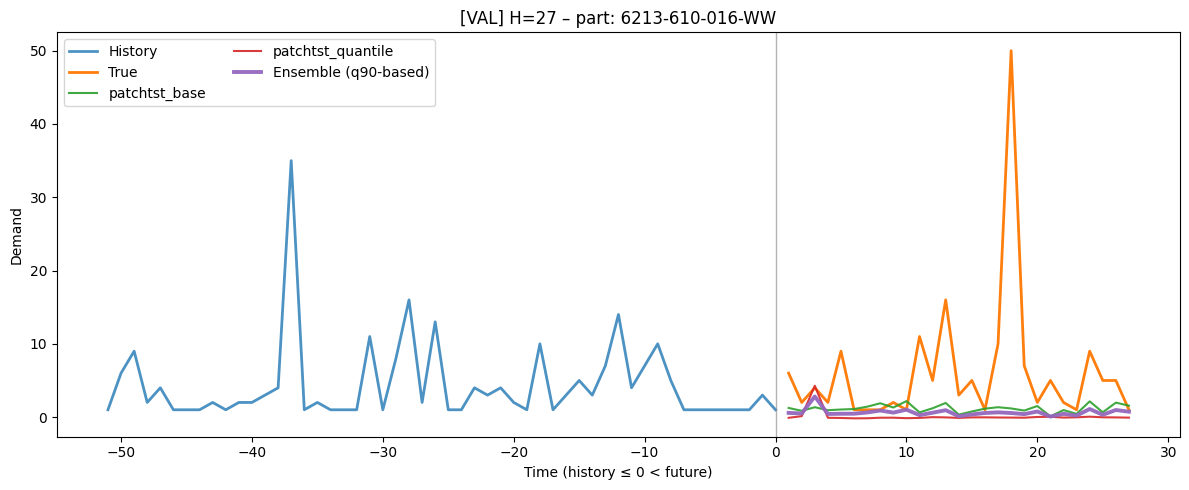

[FCAST-DBG] DMS block: Hm=3, var(Hm)=8.5748, first5=[-0.0312162, 0.320486, 5.2074]
[FCAST-DBG] DONE: H=27, var=1.06303, first5=[-0.0312162, 0.320486, 5.2074, -0.205163, -0.100345]
[PLOT-DBG] patchtst_base point(H=27): var(H)=0.305656, mean(H)=1.20538, unique(H)=27
[PLOT-DBG] patchtst_quantile point(H=27): var(H)=1.02366, mean(H)=0.0746873, unique(H)=27


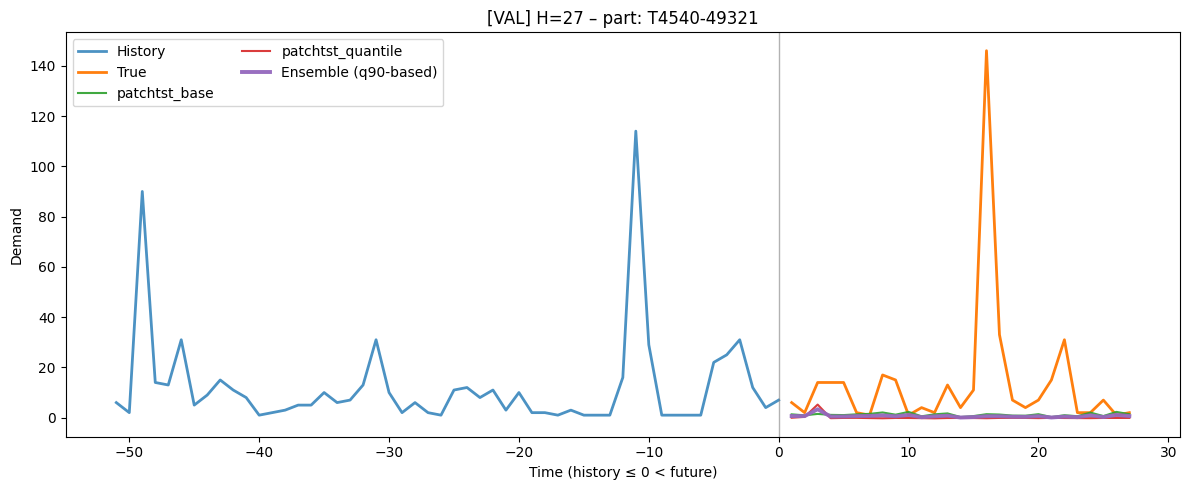

[FCAST-DBG] DMS block: Hm=3, var(Hm)=6.5117, first5=[-0.177121, 0.145594, 4.39524]
[FCAST-DBG] DONE: H=27, var=0.747889, first5=[-0.177121, 0.145594, 4.39524, -0.0596461, -0.0980243]
[PLOT-DBG] patchtst_base point(H=27): var(H)=0.203185, mean(H)=1.18014, unique(H)=27
[PLOT-DBG] patchtst_quantile point(H=27): var(H)=0.72019, mean(H)=0.0799033, unique(H)=27


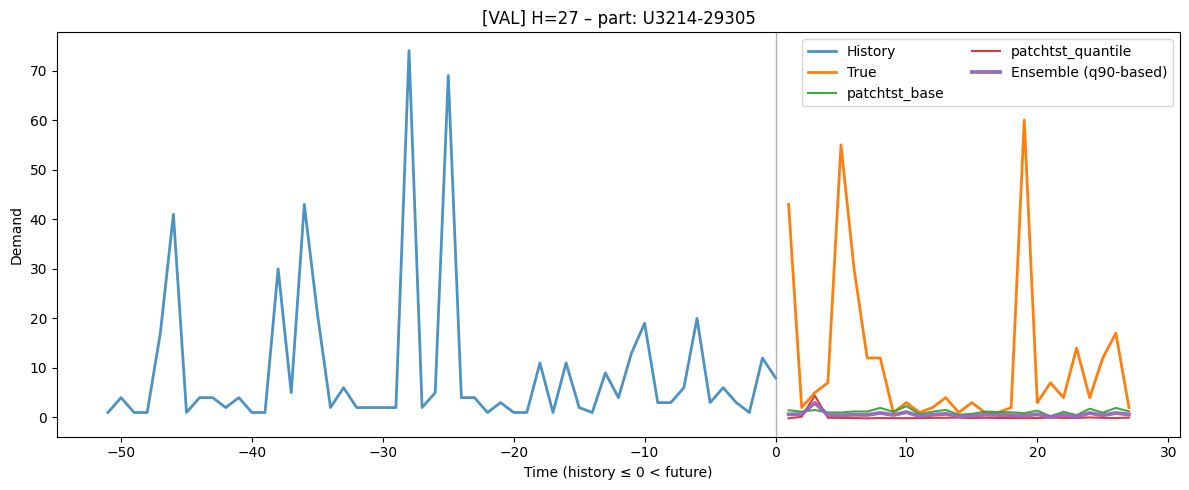

[FCAST-DBG] DMS block: Hm=3, var(Hm)=6.1391, first5=[-0.0691233, 0.169664, 4.33682]
[FCAST-DBG] DONE: H=27, var=0.708629, first5=[-0.0691233, 0.169664, 4.33682, -0.126338, -0.062665]
[PLOT-DBG] patchtst_base point(H=27): var(H)=0.242142, mean(H)=1.17462, unique(H)=27
[PLOT-DBG] patchtst_quantile point(H=27): var(H)=0.682383, mean(H)=0.132726, unique(H)=27


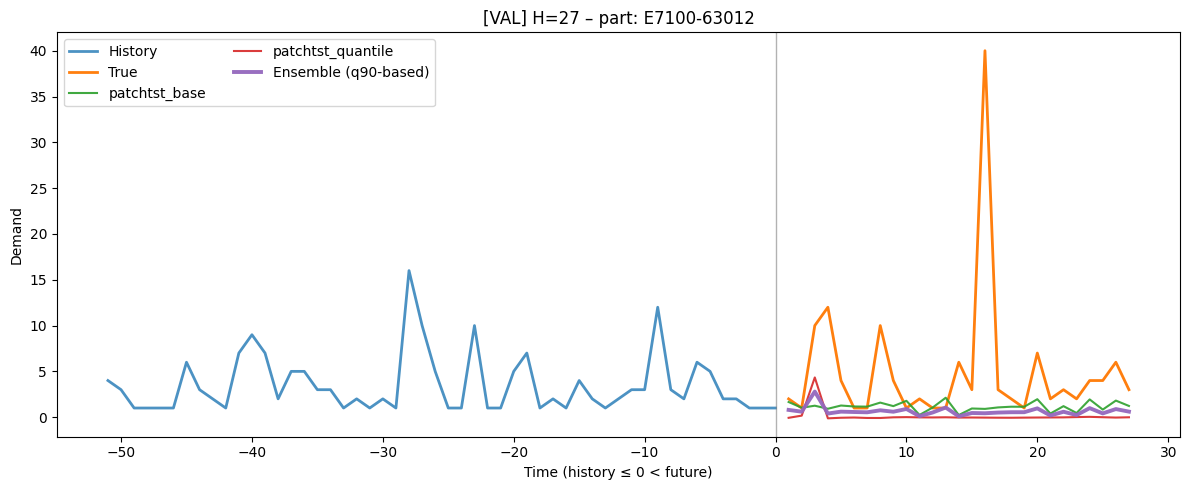

[FCAST-DBG] DMS block: Hm=3, var(Hm)=5.89046, first5=[-0.0383492, -0.0211997, 4.17393]
[FCAST-DBG] DONE: H=27, var=0.670668, first5=[-0.0383492, -0.0211997, 4.17393, -0.0651189, -0.0449]
[PLOT-DBG] patchtst_base point(H=27): var(H)=0.26735, mean(H)=1.18554, unique(H)=27
[PLOT-DBG] patchtst_quantile point(H=27): var(H)=0.645828, mean(H)=0.0877759, unique(H)=27


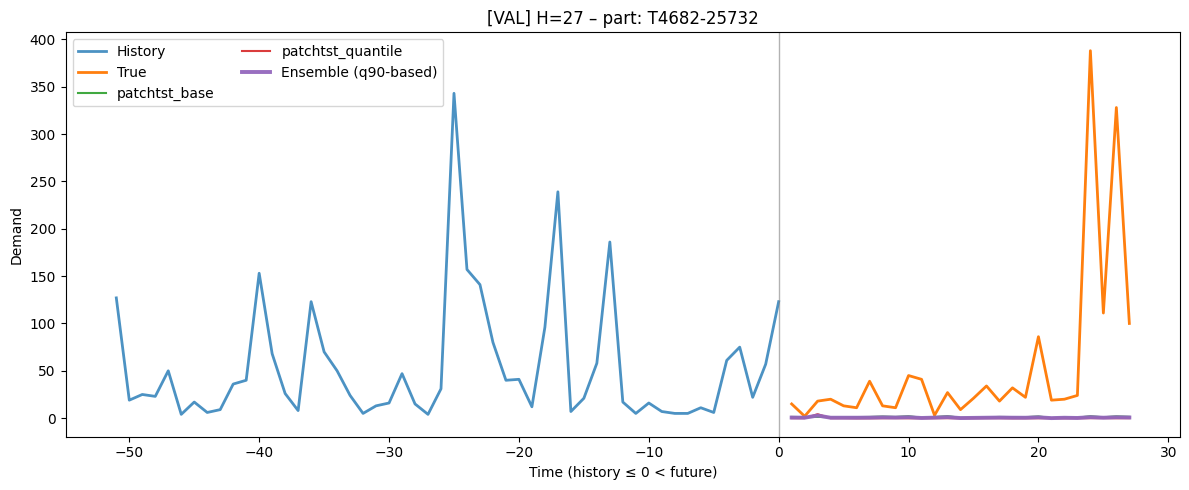

In [8]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=52, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)